[![Labellerr](https://storage.googleapis.com/labellerr-cdn/%200%20Labellerr%20template/notebook.webp)](https://www.labellerr.com)

# **Bike Helmet Detection & Violation Analysis Pipeline**

---

[![labellerr](https://img.shields.io/badge/Labellerr-BLOG-black.svg)](https://www.labellerr.com/blog)
[![Youtube](https://img.shields.io/badge/Labellerr-YouTube-b31b1b.svg)](https://www.youtube.com/@Labellerr)
[![Github](https://img.shields.io/badge/Labellerr-GitHub-green.svg)](https://github.com/Labellerr/Hands-On-Learning-in-Computer-Vision)

This notebook provides an end-to-end workflow for detecting bike helmets, identifying riders without helmets, and matching them with their vehicles. It covers repository cloning, utility imports, dataset formatting (COCO to YOLO), RT-DETR model fine-tuning, training metrics visualization, and class-based single-image & video inference.

---
## 1. Clone Utilities Library

Clones the Labellerr YOLO finetuning utilities repository to access helper functions for frame extraction and bounding box conversion.

In [ ]:
# Clone Utilities Library for helper function
# !git clone https://github.com/Labellerr/yolo_finetune_utils.git

---
## 2. Import Libraries

Loads standard scientific computing, computer vision, deep learning libraries, and the Ultralytics package required for model training and inference.

In [11]:
from ultralytics import RTDETR
import matplotlib.pyplot as plt
import cv2
import torch
import os
import numpy as np
from datetime import datetime
%matplotlib inline

---
## 3. Extract Random Frames

Extracts random sample frames from input raw videos to compile an image dataset suitable for annotation and model training.

In [ ]:
from yolo_finetune_utils.frame_extractor import extract_random_frames

# extract_random_frames(
#         paths=[r"media"],
#         total_images=30,
#         out_dir="dataset_frames",
#         jpg_quality=100,
#         seed=42
#     )

---
## 4. Convert COCO Annotations to YOLO Format

Converts ground-truth bounding box labels from COCO JSON format into normalized YOLO txt format and prepares train/val splits.

In [ ]:
from yolo_finetune_utils.coco_yolo_converter.bbox_converter import coco_to_yolo_converter

ANNOTATION_JSON = "annotations.json"
IMAGE_DIR = "dataset_frames"

# coco_to_yolo_converter(
#         json_path=ANNOTATION_JSON,
#         images_dir=IMAGE_DIR,
#         output_dir="model_dataset",
#         use_split=True,
#         train_ratio=1.0,
#         val_ratio=0.0,
#         test_ratio=0.0,
#         verbose=False
#     )

---
## 5. Check GPU Memory Status

Clears PyTorch's CUDA cache and monitors active GPU memory allocation to prevent Out-Of-Memory (OOM) errors during training.

In [12]:
torch.cuda.empty_cache()

# Check GPU memory status
print(f"Allocated: {torch.cuda.memory_allocated(0)/1024**3:.2f} GB")
print(f"Cached: {torch.cuda.memory_reserved(0)/1024**3:.2f} GB")
print(f"Free: {torch.cuda.mem_get_info(0)[0]/1024**3:.2f} GB")

Allocated: 0.43 GB
Cached: 0.43 GB
Free: 6.42 GB


---
## 6. Fine-Tune RT-DETR Model

Fine-tunes the pre-trained RT-DETR model on the custom bike helmet dataset for a specified number of epochs.

In [ ]:
model = RTDETR(r"rtdetr-l.pt")
results = model.train(
    data=r"model_dataset\dataset.yaml",    # Path to dataset YAML
    epochs=100,                        # Epoch count
    imgsz=640,                         # Image size
    batch=4,                           # Batch size
    device=0,                          # GPU index
    workers=1                          # Workers
)

---
## 7. Visualize Fine-Tuning Performance

Plots training progress plots, validation losses, and the confusion matrix saved during model fine-tuning to evaluate model convergence.

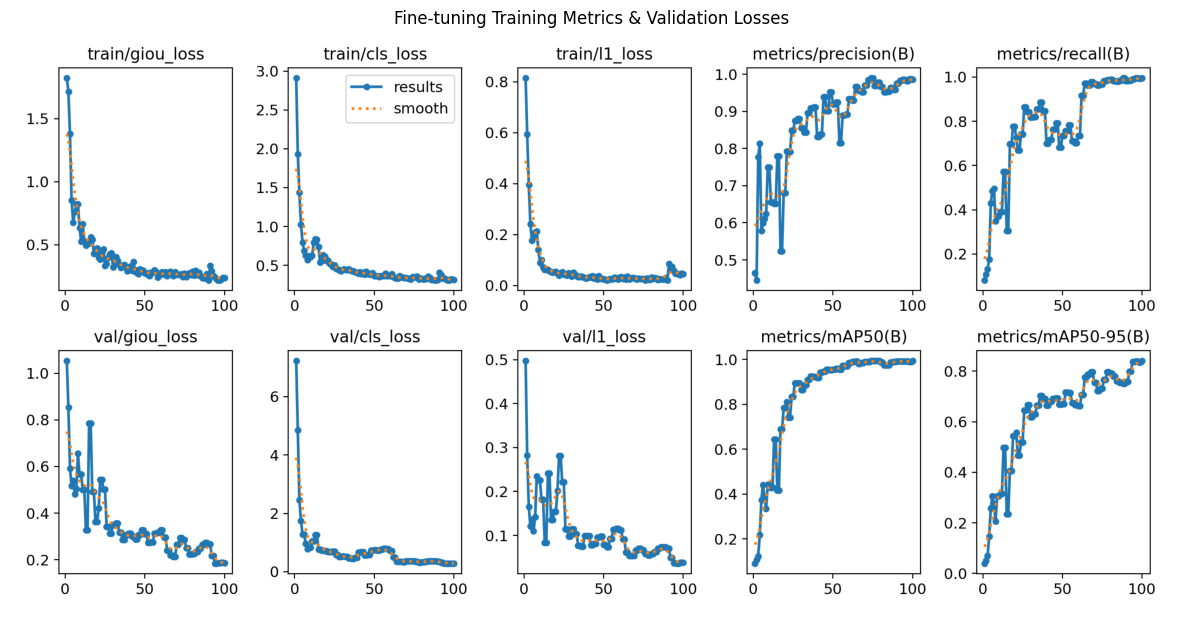

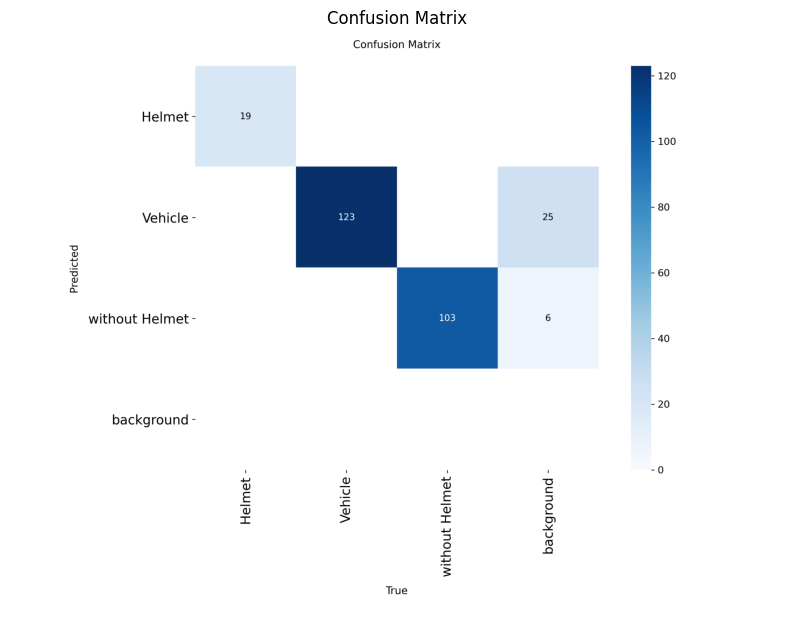

In [13]:
# Visualize Fine-tuning Metrics & Confusion Matrix
train_dir = r'runs\detect\train'
results_png = os.path.join(train_dir, 'results.png')
cm_png = os.path.join(train_dir, 'confusion_matrix.png')

if os.path.exists(results_png):
    plt.figure(figsize=(15, 10))
    img = plt.imread(results_png)
    plt.imshow(img)
    plt.axis('off')
    plt.title('Fine-tuning Training Metrics & Validation Losses')
    plt.show()
else:
    print('Training metrics file results.png not found. Make sure model fine-tuning was run.')

if os.path.exists(cm_png):
    plt.figure(figsize=(10, 8))
    img = plt.imread(cm_png)
    plt.imshow(img)
    plt.axis('off')
    plt.title('Confusion Matrix')
    plt.show()
else:
    print('Confusion matrix not found.')

---
## 8. Run Baseline Image Inference

Performs object detection using the default Ultralytics visualization on sample images from the dataset.

Running object detection inference on: model_dataset\train\images\road_1_frame_000281_t4.68s_000009.jpg


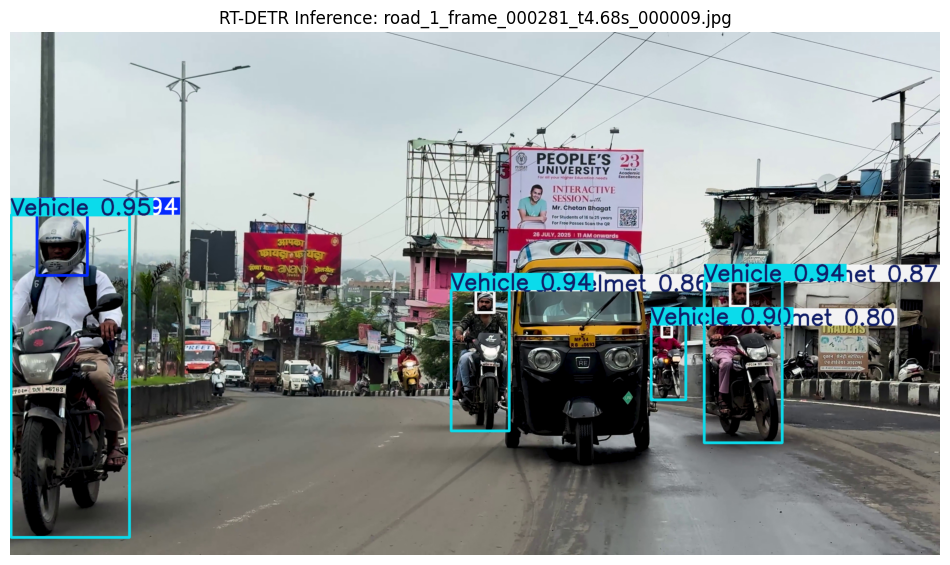

Running object detection inference on: model_dataset\train\images\road_2_frame_000366_t6.10s_000029.jpg


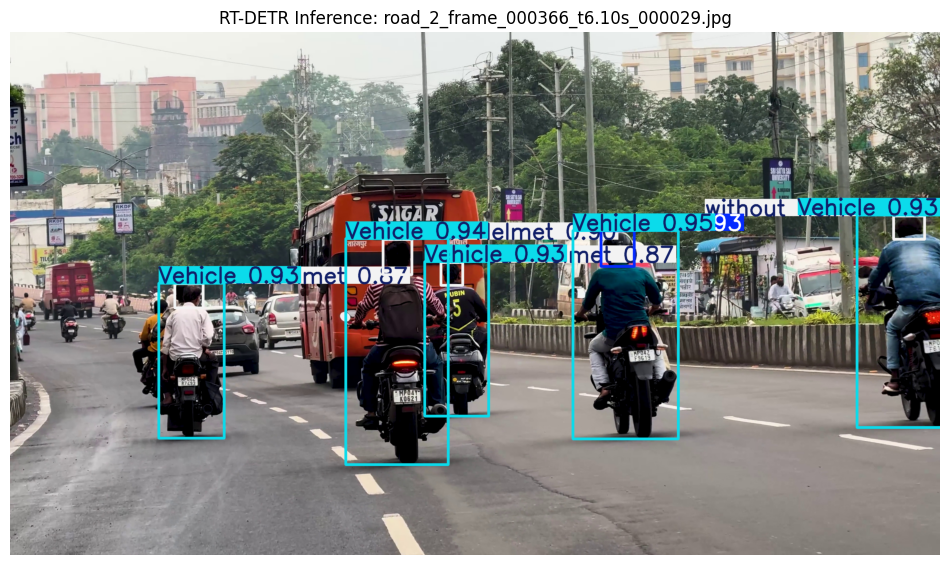

In [14]:
rt_detr_model_path = r"runs\detect\train\weights\best.pt"

def run_detector_on_folder_images(folder_path, image_names, model_path=rt_detr_model_path, conf=0.40):
    """
    Runs RT-DETR object detection inference on a specified list of image filenames from a folder,
    and visualizes the annotated bounding box predictions.
    """
    detector_model = RTDETR(model_path)
    
    for img_name in image_names:
        img_path = os.path.join(folder_path, img_name)
        if not os.path.exists(img_path):
            print(f"Warning: Image not found at {img_path}")
            continue
            
        print(f"Running object detection inference on: {img_path}")
        results = detector_model(img_path, conf=conf, verbose=False)
        
        # Plot the annotated frame
        for res in results:
            annotated_img = res.plot()
            # Convert BGR (OpenCV format) to RGB (Matplotlib format)
            annotated_img_rgb = cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB)
            
            plt.figure(figsize=(12, 8))
            plt.imshow(annotated_img_rgb)
            plt.axis("off")
            plt.title(f"RT-DETR Inference: {img_name}")
            plt.show()

# Example usage:
train_folder = r"model_dataset\train\images"
sample_images = [
    "road_1_frame_000281_t4.68s_000009.jpg",
    "road_2_frame_000366_t6.10s_000029.jpg"
]
run_detector_on_folder_images(train_folder, sample_images)

---
## 9. Run Single-Image Inference

Runs our custom class-based helmet detector and annotator on a single image, drawing high-fidelity borders, labels, and HUD metrics.

Loading RT-DETR model: runs\detect\train\weights\best.pt


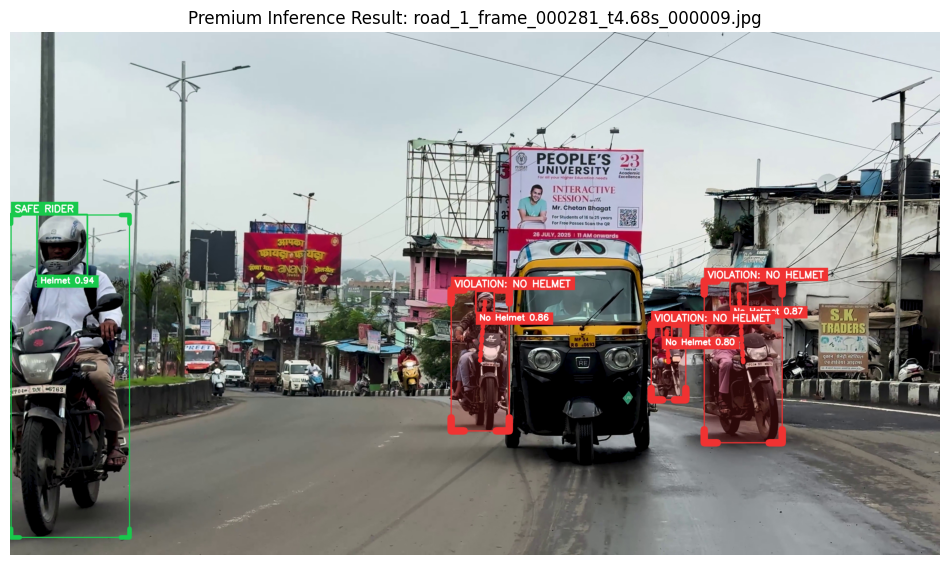

In [16]:
# Class-Based Inference on Single Images
from detect_helmet_video import DetectionConfig, HelmetDetector, VideoAnnotator, COLOR_VIOLATION, COLOR_COMPLIANT, COLOR_UNKNOWN, COLOR_TEXT

def run_image_inference(image_path, config):
    detector = HelmetDetector(config.model_path, config.iou_match_threshold)
    annotator = VideoAnnotator()
    
    image = cv2.imread(image_path)
    if image is None:
        print(f'Error: Image not found at {image_path}')
        return
        
    annotated_img = image.copy()
    h, w = image.shape[:2]
    scale = w / 1280.0
    thick_vehicle = int(max(2, round(3.5 * scale)))
    thick_head = int(max(1, round(2.0 * scale)))
    
    # Predict detections on the single image
    results = detector.model.predict(image, verbose=False, conf=config.det_conf)
    matched_vehicles, helmets, no_helmets = detector.group_and_match(results)
    
    matched_heads_indices = set()
    violation_detected = False
    
    # Draw matched vehicles
    for mv in matched_vehicles:
        v_det = mv['det']
        v_box = v_det['box']
        valid_violations = [nh for nh, ioa in mv['no_helmets'] if nh['conf'] >= config.conf_threshold]
        
        if len(valid_violations) > 0:
            violation_detected = True
            annotator.draw_semi_transparent_rect(annotated_img, v_box[0], v_box[1], v_box[2], v_box[3], COLOR_VIOLATION, 0.18)
            annotator.draw_premium_corners(annotated_img, v_box[0], v_box[1], v_box[2], v_box[3], COLOR_VIOLATION, thickness=thick_vehicle, corner_len=18)
            annotator.draw_premium_tag(annotated_img, 'VIOLATION: NO HELMET', int(v_box[0]), int(v_box[1]), COLOR_VIOLATION, COLOR_TEXT, font_scale=0.45)
            
            v_center = (int((v_box[0] + v_box[2])/2), int((v_box[1] + v_box[3])/2))
            for nh, ioa in mv['no_helmets']:
                h_box = nh['box']
                h_conf = nh['conf']
                matched_heads_indices.add(id(nh))
                cv2.rectangle(annotated_img, (int(h_box[0]), int(h_box[1])), (int(h_box[2]), int(h_box[3])), COLOR_VIOLATION, thick_head)
                h_center = (int((h_box[0] + h_box[2])/2), int((h_box[1] + h_box[3])/2))
                annotator.draw_dotted_line(annotated_img, h_center, v_center, COLOR_VIOLATION, thickness=thick_head)
                annotator.draw_premium_tag(annotated_img, f'No Helmet {h_conf:.2f}', int(h_box[0]), int(h_box[3]), COLOR_VIOLATION, COLOR_TEXT, font_scale=0.38, position='bottom')
        elif len(mv['helmets']) > 0:
            if config.show_compliant:
                annotator.draw_premium_corners(annotated_img, v_box[0], v_box[1], v_box[2], v_box[3], COLOR_COMPLIANT, thickness=int(max(1, round(2 * scale))), corner_len=12)
                annotator.draw_premium_tag(annotated_img, 'SAFE RIDER', int(v_box[0]), int(v_box[1]), COLOR_COMPLIANT, COLOR_TEXT, font_scale=0.45)
                for h, ioa in mv['helmets']:
                    h_box = h['box']
                    h_conf = h['conf']
                    matched_heads_indices.add(id(h))
                    cv2.rectangle(annotated_img, (int(h_box[0]), int(h_box[1])), (int(h_box[2]), int(h_box[3])), COLOR_COMPLIANT, thick_head)
                    annotator.draw_premium_tag(annotated_img, f'Helmet {h_conf:.2f}', int(h_box[0]), int(h_box[3]), COLOR_COMPLIANT, COLOR_TEXT, font_scale=0.38, position='bottom')
        else:
            if config.show_compliant:
                cv2.rectangle(annotated_img, (int(v_box[0]), int(v_box[1])), (int(v_box[2]), int(v_box[3])), COLOR_UNKNOWN, thick_head)
                annotator.draw_premium_tag(annotated_img, 'Vehicle', int(v_box[0]), int(v_box[1]), COLOR_UNKNOWN, COLOR_TEXT, font_scale=0.45)

    # Draw unmatched heads/helmets
    for nh in no_helmets:
        if id(nh) in matched_heads_indices:
            continue
        h_box = nh['box']
        h_conf = nh['conf']
        cv2.rectangle(annotated_img, (int(h_box[0]), int(h_box[1])), (int(h_box[2]), int(h_box[3])), COLOR_UNKNOWN, thick_head)
        annotator.draw_premium_tag(annotated_img, f'No Helmet {h_conf:.2f}', int(h_box[0]), int(h_box[3]), COLOR_UNKNOWN, COLOR_TEXT, font_scale=0.38, position='bottom')

    for h in helmets:
        if id(h) in matched_heads_indices:
            continue
        h_box = h['box']
        h_conf = h['conf']
        cv2.rectangle(annotated_img, (int(h_box[0]), int(h_box[1])), (int(h_box[2]), int(h_box[3])), COLOR_COMPLIANT, thick_head)
        annotator.draw_premium_tag(annotated_img, f'Helmet {h_conf:.2f}', int(h_box[0]), int(h_box[3]), COLOR_COMPLIANT, COLOR_TEXT, font_scale=0.38, position='bottom')

    # Convert BGR to RGB and display
    rgb_img = cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(12, 8))
    plt.imshow(rgb_img)
    plt.axis('off')
    plt.title(f'Premium Inference Result: {os.path.basename(image_path)}')
    plt.show()

# Run premium inference
config = DetectionConfig(
    video_path='',
    model_path=rt_detr_model_path,
    conf_threshold=0.80,
    det_conf=0.25,
    show_compliant=True
)
test_image = os.path.join('model_dataset', 'train', 'images', 'road_1_frame_000281_t4.68s_000009.jpg')
run_image_inference(test_image, config)

---
## 10. Run Video Pipeline

Executes the full class-based violation detection and premium overlay annotation pipeline on an input video file.

In [17]:
# Run end-to-end helmet detection and annotation pipeline on video
from detect_helmet_video import DetectionConfig, VideoProcessor

config = DetectionConfig(
    video_path=r'media\road_1.mp4',
    output_path=r'media\road_1_annotated.mp4',
    conf_threshold=0.80,
    det_conf=0.25,
    save_crops=False,  # Set to True to save violation crops to disk
    show_compliant=True
)

processor = VideoProcessor(config)
processor.process()

Loading RT-DETR model: runs\detect\train\weights\best.pt
Saving crops is disabled.
Video Info: 3840x2160 | 60.0 FPS | 722 frames total


Processing frames: 100%|██████████| 722/722 [02:10<00:00,  5.52it/s]


Processing finished.
Annotated video saved: media\road_1_annotated.mp4


---

## 👨‍💻 About Labellerr's Hands-On Learning in Computer Vision

Thank you for exploring this **Labellerr Hands-On Computer Vision Cookbook**! We hope this notebook helped you learn, prototype, and accelerate your vision projects.  
Labellerr provides ready-to-run Jupyter/Colab notebooks for the latest models and real-world use cases in computer vision, AI agents, and data annotation.

---
## 🧑‍🔬 Check Our Popular Youtube Videos

Whether you're a beginner or a practitioner, our hands-on training videos are perfect for learning custom model building, computer vision techniques, and applied AI:

- [How to Fine-Tune YOLO on Custom Dataset](https://www.youtube.com/watch?v=pBLWOe01QXU)  
  Step-by-step guide to fine-tuning YOLO for real-world use—environment setup, annotation, training, validation, and inference.
- [Build a Real-Time Intrusion Detection System with YOLO](https://www.youtube.com/watch?v=kwQeokYDVcE)  
  Create an AI-powered system to detect intruders in real time using YOLO and computer vision.
- [Finding Athlete Speed Using YOLO](https://www.youtube.com/watch?v=txW0CQe_pw0)  
  Estimate real-time speed of athletes for sports analytics.
- [Object Counting Using AI](https://www.youtube.com/watch?v=smsjBBQcIUQ)  
  Learn dataset curation, annotation, and training for robust object counting AI applications.
- [How I Fixed My Biggest Annotation Nightmare with Labellerr](https://www.youtube.com/watch?v=hlcFdiuz_HI) – Solving complex annotation for ML engineers.
- [Explore Your Dataset with Labellerr's AI](https://www.youtube.com/watch?v=LdbRXYWVyN0) – Auto-tagging, object counting, image descriptions, and dataset exploration.
- [Boost AI Image Annotation 10X with Labellerr's CLIP Mode](https://www.youtube.com/watch?v=pY_o4EvYMz8) – Refine annotations with precision using CLIP mode.
- [Boost Data Annotation Accuracy and Efficiency with Active Learning](https://www.youtube.com/watch?v=lAYu-ewIhTE) – Speed up your annotation workflow using Active Learning.

> 👉 **Subscribe** for Labellerr's deep learning, annotation, and AI tutorials, or watch videos directly alongside notebooks!

---

## 🤝 Stay Connected

- **Website:** [https://www.labellerr.com/](https://www.labellerr.com/)
- **Blog:** [https://www.labellerr.com/blog/](https://www.labellerr.com/blog/)
- **GitHub:** [Labellerr/Hands-On-Learning-in-Computer-Vision](https://github.com/Labellerr/Hands-On-Learning-in-Computer-Vision)
- **LinkedIn:** [Labellerr](https://in.linkedin.com/company/labellerr)
- **Twitter/X:** [@Labellerr1](https://x.com/Labellerr1)

*Happy learning and building with Labellerr!*
